## 이미지를 인식하는 원리

In [15]:
# TensorFlow 안에 들어있는 MNIST 데이터셋을 불러오기
# MNIST는 0~9까지의 손글씨 숫자 이미지 데이터
from tensorflow.keras.datasets import mnist


# 정답(label)을 원-핫 인코딩 형태로 바꿔주는 함수
# 예: 숫자 3 → [0,0,0,1,0,0,0,0,0,0]
# (이 코드에서는 아직 사용하지 않지만, 나중에 필요해서 미리 불러옴)
from tensorflow.keras.utils import to_categorical


# 그래프나 이미지를 화면에 보여주기 위한 라이브러리
# MNIST 숫자 이미지를 시각적으로 확인할 때 사용
import matplotlib.pyplot as plt

# 파이썬 시스템 관련 기능을 제공하는 라이브러리
# (프로그램 종료, 에러 처리 등에 사용)
# 이 코드에서는 아직 사용하지 않음
import sys


# MNIST 데이터를 불러오는 코드
# load_data()를 실행하면 데이터가 자동으로 다운로드됨
# 그리고 학습용 / 테스트용 데이터로 나누어 반환됨
(X_train,y_train),(X_test,y_test)=mnist.load_data()

# X_train.shape[0] → 학습용 이미지의 개수
# %d 는 정수를 출력하겠다는 의미
print("학습셋 이미지 수 : %d 개" % (X_train.shape[0]))

# X_test.shape[0] → 테스트용 이미지의 개수
print("테스트 셋 이미지수 : %d 개" % (X_test.shape[0]))

print(X_train.shape)


학습셋 이미지 수 : 60000 개
테스트 셋 이미지수 : 10000 개
(60000, 28, 28)


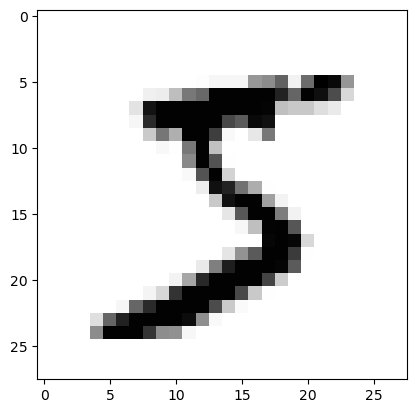

In [16]:
# X_train은 MNIST 학습용 이미지 데이터
# X_train[0] 은 학습 데이터 중 "첫 번째 숫자 이미지" 한 장
# 이 이미지는 28 x 28 크기의 흑백 이미지임
#
# imshow() 함수는 배열 데이터를 이미지처럼 화면에 보여줌
# cmap='Greys' 는 색상 표현을 흑백(그레이스케일)로 지정
# → 숫자는 밝게, 배경은 어둡게 보이게 됨

plt.imshow(X_train[0],cmap='Greys')

# 지금까지 준비한 이미지(그래프)를 실제 화면에 출력
# 이 줄이 없으면 이미지가 보이지 않을 수 있음
plt.show()

In [17]:
# X_train[0] : MNIST 학습 데이터 중 첫 번째 숫자 이미지
# 이 이미지는 28 x 28 크기의 흑백 이미지이며
# 각 칸에는 0 ~ 255 사이의 숫자(픽셀 밝기 값)가 들어 있음

# 바깥쪽 for문
# 이미지의 "세로 줄(행)"을 하나씩 꺼내는 반복문
for x in X_train[0]:
    # 안쪽 for문
    # 한 줄(x) 안에 들어 있는 픽셀 값들을
    # 왼쪽에서 오른쪽으로 하나씩 꺼냄
    for i in x:
    # sys.stdout.write()는 print()와 비슷하지만
    # 자동으로 줄바꿈을 하지 않음
    #
    # "%-3s" % i 의 의미:
    #  - %s  : 값을 문자열 형태로 출력
    #  - 3   : 3칸의 공간을 확보
    #  - -   : 왼쪽 정렬
    #
    # → 각 픽셀 숫자를 칸 맞춰서 출력하기 위함
        sys.stdout.write("%-3s" % i)
    # 한 행(가로 28칸)을 모두 출력했으면
    # 줄바꿈을 해서 다음 행으로 이동
    sys.stdout.write('\n')

0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  3  18 18 18 12613617526 1662552471270  0  0  0  
0  0  0  0  0  0  0  0  30 36 94 15417025325325325325322517225324219564 0  0  0  0  
0  0  0  0  0  0  0  49 23825325325325325325325325325193 82 82 56 39 0  0  0  0  0  
0  0  0  0  0  0  0  18 2192532532532532531981822472410  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  80 15610725325320511 0  43 1540  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  14 1  15425390 0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  1392531902  0  0  0  0  0  0  0 

In [18]:
# ===============================
# 1. 학습용 이미지 데이터 전처리
# ===============================

# 원래 X_train의 모양:
# (이미지 개수, 세로 픽셀, 가로 픽셀)
# → (60000, 28, 28)

# Dense(완전연결층) 신경망은
# (데이터 개수, 특징 개수) 형태만 받기 때문에
# 28 x 28 이미지를 784개의 숫자로 한 줄로 펼침

X_train=X_train.reshape(X_train.shape[0],784)

# 픽셀 값은 원래 정수형(int)이지만
# 딥러닝 계산(미분, 가중치 업데이트)은
# 실수(float)가 필요하므로 자료형을 실수로 변환
X_train=X_train.astype('float64')

# 픽셀 값의 범위는 0 ~ 255
# 255로 나누어 0 ~ 1 사이 값으로 만들어 줌
# → 정규화(normalization)
# → 학습 속도 향상 + 안정적인 학습
X_train=X_train/255

# ===============================
# 2. 테스트용 이미지 데이터 전처리
# ===============================

# 테스트 데이터도 학습 데이터와
# 반드시 "완전히 동일한 방식"으로 전처리해야 함
# (reshape → float 변환 → 정규화)
X_test=X_test.reshape(X_test.shape[0],784).astype('float64')/255


# ===============================
# 3. 정답(label) 확인
# ===============================

# 첫 번째 학습 이미지의 실제 정답 숫자를 출력
# 아직은 0~9 사이의 "정수" 값
print("class : %d" % (y_train[0]))

# ===============================
# 4. 정답을 원-핫 인코딩으로 변환
# ===============================

# to_categorical:
# 정수 형태의 정답을 신경망이 이해하기 쉬운
# 원-핫 벡터 형태로 변환
#
# 예:
# 5 → [0,0,0,0,0,1,0,0,0,0]
#
# 10은 클래스 개수 (0~9 → 총 10개)
y_train = to_categorical(y_train, 10)


# 테스트 정답도 학습 정답과
# 동일한 방식으로 원-핫 인코딩
y_test=to_categorical(y_test,10)


# ===============================
# 5. 변환된 정답 확인
# ===============================

# 첫 번째 학습 데이터의 원-핫 인코딩 결과 출력
print(y_train[0])

class : 5
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [1]:
# ===============================
# 1. 딥러닝에 필요한 라이브러리 불러오기
# ===============================

# Sequential 모델: 층(layer)을 위에서 아래로 순서대로 쌓는 모델
from tensorflow.keras.models import Sequential
# Dense 층: 완전연결층 (모든 입력 노드와 출력 노드가 연결됨)
from tensorflow.keras.layers import Dense
# 학습을 도와주는 콜백 함수들
# EarlyStopping: 성능이 더 이상 좋아지지 않으면 학습 중단
# ModelCheckpoint: 가장 성능 좋은 모델 저장
# (이 코드에서는 아직 사용하지 않지만 보통 함께 사용함)
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping

# MNIST 손글씨 숫자 데이터셋 불러오기
from tensorflow.keras.datasets import mnist
# 정답(label)을 원-핫 인코딩으로 바꿔주는 함수
from tensorflow.keras.utils import to_categorical

# 그래프나 이미지를 출력할 때 사용하는 라이브러리
# (이번 코드에서는 직접 사용하지 않음)
import matplotlib.pyplot as plt

# 수치 계산을 위한 라이브러리
# (이번 코드에서는 직접 사용하지 않음)
import numpy as np
# 파일 및 폴더 관련 기능을 위한 라이브러리
# (이번 코드에서는 직접 사용하지 않음)
import os


# ===============================
# 2. MNIST 데이터 불러오기
# ===============================

# MNIST 데이터를 학습용과 테스트용으로 나누어 불러옴
# X_train : 학습용 이미지 (60000장)
# y_train : 학습용 정답 (0~9 숫자)
# X_test  : 테스트용 이미지 (10000장)
# y_test  : 테스트용 정답
(X_train,y_train),(X_test,y_test)=mnist.load_data()


# ===============================
# 3. 이미지 데이터 전처리
# ===============================

# 원래 X_train의 형태:
# (이미지 개수, 세로 픽셀, 가로 픽셀)
# → (60000, 28, 28)

# Dense 신경망은 (데이터 개수, 특징 개수) 형태만 받기 때문에
# 28 x 28 이미지를 784개의 숫자로 한 줄로 펼침
# 또한 계산을 위해 실수(float32)로 변환하고
# 픽셀 값을 0~1 사이로 만들기 위해 255로 나눔
X_train=X_train.reshape(X_train.shape[0],784).astype('float32')/255

# 테스트 이미지도 학습 이미지와
# 반드시 동일한 방식으로 전처리해야 함
X_test=X_test.reshape(X_test.shape[0],784).astype('float32')/255


# ===============================
# 4. 정답(label) 데이터 전처리
# ===============================

# y_train은 현재 0~9 사이의 정수 값
# 이를 신경망이 이해하기 쉬운 원-핫 인코딩 형태로 변환
# 예: 3 → [0,0,0,1,0,0,0,0,0,0]
# 10은 클래스 개수 (숫자 0~9)
y_train=to_categorical(y_train,10)

# 테스트 정답도 동일하게 원-핫 인코딩
y_test=to_categorical(y_test,10)

# ===============================
# 5. 신경망 모델 생성
# ===============================

# Sequential 모델 생성 (아직 비어 있는 상태)
model=Sequential()

# 첫 번째 Dense 층 (은닉층)
# 입력값 784개를 받아서
# 512개의 뉴런으로 특징을 추출
# relu 활성화 함수는 음수는 0으로 만들고 양수는 그대로 사용
model.add(Dense(512,input_dim=784,activation='relu'))

# 두 번째 Dense 층 (출력층)
# 숫자 0~9 → 총 10개 클래스
# softmax는 각 숫자일 확률을 계산해 줌
model.add(Dense(10,activation='softmax'))

# ===============================
# 6. 모델 구조 요약 출력
# ===============================

# 각 층의 구조, 파라미터 개수 등을 한눈에 확인
model.summary()

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)



## ✅ 결론 한 줄

> **Dense(완전연결층) 모델을 쓰면
> `(60000, 28, 28)` → `(60000, 784)`
> 이렇게 2차원으로 바꿔주는 과정이 반드시 필요합니다.**

---

## 🧠 왜 “반드시” 해야 할까?

### 📌 Dense 층이 받을 수 있는 입력 형태

Dense는 이렇게 생긴 데이터만 이해합니다:

```text
(데이터 개수, 특징 개수)
```

즉,

```python
(None, 784)
```

👉 **한 줄짜리 숫자 묶음만 받음**

---

## 🔍 MNIST 원래 모양

```python
(60000, 28, 28)
```

의미:

* 60000장 이미지
* 각 이미지는 28×28 격자

👉 이건 **3차원**이라 Dense가 못 씀 ❌

---

## 🔄 그래서 이렇게 바꿈

```python
X_train = X_train.reshape(60000, 784)
```

또는 안전하게:

```python
X_train = X_train.reshape(X_train.shape[0], 784)
```

👉 이미지 한 장을:

```
28 × 28  →  784
```

로 **쭉 펼치는 작업**

---

## 🧠 비유로 딱 이해하기

* **원래 상태** `(28,28)`
  👉 바둑판 종이

* **reshape 후** `(784)`
  👉 바둑판을 찢어서 한 줄로 붙인 것

Dense는
👉 **바둑판 ❌ / 한 줄 ⭕**

---

## ❗ 언제 안 해도 되냐면?

### CNN(합성곱 신경망)을 쓸 때

CNN은 이미지 구조를 이해할 수 있어서:

```python
(60000, 28, 28, 1)
```

이런 **4차원 형태**를 그대로 사용합니다.

👉 CNN = reshape 불필요
👉 Dense = reshape 필수

---

## 🔥 최종 정리 (이건 꼭 기억하세요)

* `(60000, 28, 28)` → **3차원**
* Dense 모델 → **2차원 필요**
* 그래서 `(60000, 784)`로 바꿔야 함

---

지금 이해한 이 한 가지가
👉 **딥러닝 입력 형태 개념의 핵심**입니다.



In [ ]:
# ===============================
# 1. 모델 학습 규칙 설정 (compile)
# ===============================

# model.compile은
# "이 모델을 어떤 방식으로 학습시킬지"를 정하는 단계

model.compile(    # loss(손실 함수):
                # 모델이 얼마나 틀렸는지를 계산하는 기준
                # 현재 문제는 0~9 숫자 분류 문제이고
                # 정답이 원-핫 인코딩 되어 있으므로
                # categorical_crossentropy를 사용
              loss='categorical_crossentropy',
               # optimizer(최적화 알고리즘):
                # 손실 값을 줄이기 위해
                # 가중치를 어떻게 업데이트할지 결정
                # adam은 가장 널리 쓰이고 안정적인 방법
              optimizer='adam',
                # metrics:
                # 학습 중에 함께 보고 싶은 평가 지표
                # 여기서는 정확도(accuracy)를 확인
              metrics=['accuracy'])



# ===============================
# 2. 모델 저장 경로 설정
# ===============================

# 학습 중 가장 성능이 좋은 모델을
# 파일로 저장할 경로와 파일 이름

modelpath='./MNIST_MLP.keras'
checkpointer=ModelCheckpoint(filepath=modelpath,# 모델을 저장할 경로
                             monitor='val_loss', # 기준 지표: 검증 데이터의 손실값
                             verbose=1, # 모델 저장 시 메시지 출력
                             save_best_only=True) # 가장 좋은 성능일 때만 저장


# ===============================
# 4. EarlyStopping 설정
# ===============================

# EarlyStopping:
# 성능이 더 이상 좋아지지 않으면
# 학습을 자동으로 멈춰주는 기능
early_stopping_callback=EarlyStopping(monitor='val_loss',# 검증 손실값을 기준으로 판단
                                      patience=10) # 10번 연속 개선이 없으면 학습 종료


# ===============================
# 5. 모델 학습 (fit)
# ===============================

# model.fit:
# 실제로 신경망을 학습시키는 단계
history=model.fit(X_train,# 학습용 입력 데이터
                  y_train,  # 학습용 정답 데이터

                  # 학습 데이터 중 25%를 떼어내어
                  # 검증(validation) 데이터로 사용
                  validation_split=0.25,
                   # 전체 학습 데이터를 최대 30번 반복
                  epochs=30,
                   # 한 번에 200개 데이터씩 묶어서 학습
                  batch_size=200,

                  # 학습 과정을 화면에 출력하지 않음
                  # (1로 바꾸면 진행 상황이 출력됨)
                  verbose=0,

                   # 학습 중 사용할 콜백 함수들
                   # - 성능 안 좋아지면 멈추기
                   # - 최고 성능 모델 저장
                  callbacks=[early_stopping_callback,checkpointer])

# ===============================
# 6. 테스트 데이터로 최종 성능 평가
# ===============================

# model.evaluate:
# 학습에 전혀 사용하지 않은 테스트 데이터로
# 모델의 진짜 성능을 측정
#
# 반환값:
# [손실값(loss), 정확도(accuracy)]


# 테스트 정확도를 소수점 4자리까지 출력
print("\n TEST Acuuracy :%.4f" % (model.evaluate(X_test,y_test)[1]))



Epoch 1: val_loss improved from None to 0.19312, saving model to ./MNIST_MLP.keras

Epoch 1: finished saving model to ./MNIST_MLP.keras

Epoch 2: val_loss improved from 0.19312 to 0.14244, saving model to ./MNIST_MLP.keras

Epoch 2: finished saving model to ./MNIST_MLP.keras

Epoch 3: val_loss improved from 0.14244 to 0.11060, saving model to ./MNIST_MLP.keras

Epoch 3: finished saving model to ./MNIST_MLP.keras

Epoch 4: val_loss improved from 0.11060 to 0.10392, saving model to ./MNIST_MLP.keras

Epoch 4: finished saving model to ./MNIST_MLP.keras

Epoch 5: val_loss improved from 0.10392 to 0.09559, saving model to ./MNIST_MLP.keras

Epoch 5: finished saving model to ./MNIST_MLP.keras

Epoch 6: val_loss improved from 0.09559 to 0.08848, saving model to ./MNIST_MLP.keras

Epoch 6: finished saving model to ./MNIST_MLP.keras

Epoch 7: val_loss improved from 0.08848 to 0.08492, saving model to ./MNIST_MLP.keras

Epoch 7: finished saving model to ./MNIST_MLP.keras

Epoch 8: val_loss did 

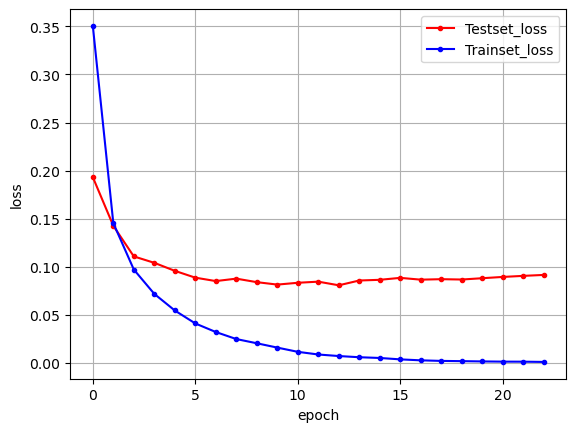

In [ ]:
# ===============================
# 1. 학습 과정에서 기록된 손실(loss) 값 꺼내기
# ===============================

# history는 model.fit() 실행 후 반환된 객체
# history.history 안에는
# epoch마다의 학습 결과가 딕셔너리 형태로 저장되어 있음

# 'val_loss' :
# 검증 데이터(validation set)에 대한 손실값
# → 과적합 여부를 판단할 때 가장 중요

y_vloss=history.history['val_loss']

# 'loss' :
# 학습 데이터(train set)에 대한 손실값
# → 모델이 학습 데이터를 얼마나 잘 맞추고 있는지
y_loss=history.history['loss']


# ===============================
# 2. x축(에포크 번호) 만들기
# ===============================

# y_loss의 길이 = 학습이 실제로 진행된 epoch 수
# 예: epoch가 18번이면 len(y_loss) = 18

# np.arange(n):
# 0부터 n-1까지 숫자를 차례대로 만들어 줌
# → [0, 1, 2, ..., n-1]
x_len=np.arange(len(y_loss))


# ===============================
# 3. 검증 손실 그래프 그리기
# ===============================

# x축 : epoch 번호
# y축 : 검증 손실(val_loss)
# marker='.' : 각 epoch 값을 점으로 표시
# c='red' : 선 색상을 빨간색으로 지정
# label : 범례(legend)에 표시될 이름
plt.plot(x_len,y_vloss,marker='.',c='red',label='Testset_loss')


# ===============================
# 4. 학습 손실 그래프 그리기
# ===============================

# x축 : epoch 번호
# y축 : 학습 손실(loss)
# 파란색 선으로 표시
plt.plot(x_len,y_loss,marker='.',c='blue',label='Trainset_loss')



# ===============================
# 5. 범례 표시
# ===============================

# 그래프 오른쪽 위에
# 각 선이 무엇을 의미하는지 표시
plt.legend(loc='upper right')

# ===============================
# 6. 격자(grid) 표시
# ===============================

# 그래프에 눈금선을 추가해서
# 값의 변화가 더 잘 보이게 함
plt.grid()

# ===============================
# 7. x축, y축 이름 설정
# ===============================

# x축 이름: epoch (학습 반복 횟수)
plt.xlabel('epoch')

# y축 이름: loss (오차 크기)
plt.ylabel('loss')



# ===============================
# 8. 그래프 화면에 출력
# ===============================

# 지금까지 설정한 그래프를
# 실제 화면에 보여줌
plt.show()

## 컨볼루션 신경망 실행하기

아주 **핵심 질문**이에요 👍
CNN 이해의 고비를 딱 짚었어요.
결론부터 말하면 👇

> **❌ 2×2로 “정해진 것”은 절대 아님**
> **⭕ 3×3도 가능함**
> 하지만 **2×2가 가장 많이 쓰이는 이유**가 있어요.

아주 쉽게, 그림 떠올리듯 설명할게요.

---

## 🔹 MaxPooling이 하는 일 (한 줄 요약)

👉 **여러 칸 중에서 가장 중요한 값(최댓값) 하나만 남긴다**

---

## 🔹 왜 2×2를 쓰면 “절반”이 되냐?

예를 들어 입력이 이런 크기라고 해볼게요 👇

```
28 × 28
```

### 🔸 pool_size = (2,2)

👉 가로·세로를 **2칸씩 묶음**

```
(2×2 묶음) → 1칸으로 압축
```

결과:

```
28 → 14
28 → 14
```

즉,

```
28×28 → 14×14
```

✔ 그래서 **“절반으로 줄어든다”**고 말하는 거예요

---

## 🔹 그럼 3×3은 안 돼?

### ❗ 결론: **된다**

```python
model.add(MaxPooling2D(pool_size=(3,3)))
```

문법적으로도 ✔
실행도 ✔

---

## 🔹 그럼 왜 다들 2×2만 쓰냐?

### 이유 ① 정보 손실이 너무 큼

3×3은 이렇게 됨 👇

```
3×3 → 1개
```

👉 **9칸 중 1칸만 남김**

반면

```
2×2 → 1개 (4칸 중 1칸)
```

✔ 3×3은 **너무 과격하게 줄임**

---

### 이유 ② 크기가 애매해짐

예:

```
28 ÷ 3 = 9.33 ❌
```

👉 딱 안 나눠짐
→ 가장자리가 잘리거나 패딩 필요
→ 구조 복잡해짐

반면:

```
28 ÷ 2 = 14 ⭕
```

✔ 깔끔

---

### 이유 ③ 경험적으로 2×2가 제일 안정적

CNN 역사에서:

* 2×2 pooling
* stride = 2

👉 **성능 + 안정성 + 계산 효율**
👉 거의 “표준”

---

## 🔹 3×3 Pooling은 언제 쓰나?

✔ **이미지가 아주 클 때**
✔ **정보가 굉장히 많을 때**
✔ **강하게 압축하고 싶을 때**

예:

* 위성 이미지
* 의료 영상
* 고해상도 사진

MNIST (28×28)는 ❌ **너무 작음**

---

## 🔹 숫자로 직관 비교

| pool_size | 줄어드는 정도 | 정보 손실 |
| --------- | ------- | ----- |
| 2×2       | 4 → 1   | 적당    |
| 3×3       | 9 → 1   | 큼     |
| 4×4       | 16 → 1  | 매우 큼  |

---

## 🔹 CNN 초보자 공식 공식

> 📌 **작은 이미지 → 2×2**
> 📌 **큰 이미지 → 2×2 또는 가끔 3×3**

---

## 🔹 한 문장으로 정리

> **2×2는 관례이자 최적의 타협**
> **3×3은 가능하지만 MNIST에서는 손해**

---



In [ ]:
# ===============================
# 1. 필요한 라이브러리 불러오기
# ===============================

# Sequential : 층을 순서대로 쌓는 가장 기본적인 신경망 모델

from tensorflow.keras.models import Sequential
# 신경망을 구성하는 다양한 레이어들
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D
# 학습 중 모델 저장과 조기 종료를 위한 콜백
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping
# MNIST 손글씨 숫자 데이터셋
from tensorflow.keras.datasets import mnist
# 정답 라벨을 원-핫 인코딩으로 바꿔주는 함수
from tensorflow.keras.utils import to_categorical
# 그래프 그리기용 (이번 코드에서는 직접 사용하지 않음)
import matplotlib.pyplot as plt
# 수치 계산용 라이브러리
import numpy as np


# ===============================
# 2. MNIST 데이터 불러오기
# ===============================

# MNIST 데이터는 이미 학습용/테스트용으로 나뉘어 있음
(X_train,y_train),(X_test,y_test)=mnist.load_data()

# 학습용 이미지 데이터의 형태 확인
print(X_train.shape)
# (60000, 28, 28)
# → 28x28 크기의 흑백 이미지가 60000장


# ===============================
# 3. 데이터 전처리 (CNN용 형태 + 정규화)
# ===============================

# CNN은 (개수, 높이, 너비, 채널) 형태의 입력을 기대함
# 기존: (60000, 28, 28)
# 변경: (60000, 28, 28, 1)

# astype('float32') : 계산을 빠르고 안정적으로 하기 위함
# /255 : 픽셀 값을 0~1 사이로 정규화
X_train=X_train.reshape(X_train.shape[0],28,28,1).astype('float32') /255
X_test=X_test.reshape(X_test.shape[0],28,28,1).astype('float32')/255
# 정답 라벨을 원-핫 인코딩으로 변환
# 예: 3 → [0,0,0,1,0,0,0,0,0,0]
y_train=to_categorical(y_train)
y_test=to_categorical(y_test)

# 전처리 후 학습 데이터 형태 확인
print(X_train.shape)
# (60000, 28, 28, 1)


# ===============================
# 4. CNN 모델 구성
# ===============================

# Sequential 모델 생성
model=Sequential()

# ---- 첫 번째 합성곱 층 ----
# 32개의 필터를 사용해 이미지의 기본적인 특징(선, 모서리 등)을 추출
# kernel_size=(3,3) : 3x3 필터 사용
# input_shape : 입력 이미지 크기
# relu : 음수 제거 → 학습 안정
model.add(Conv2D(32,
                 kernel_size=(3,3),
                 input_shape=(28,28,1),
                 activation='relu'))

# ---- 두 번째 합성곱 층 ----
# 더 많은 필터(64개)를 사용해 복잡한 특징을 학습
model.add(Conv2D(64,
                 (3,3),
                 activation='relu'))

# ---- 맥스 풀링 ----
# 2x2 영역에서 가장 큰 값만 남김
# 이미지 크기를 절반으로 줄여 계산량 감소 + 과적합 방지
model.add(MaxPooling2D(pool_size=(2,2)))

# ---- 드롭아웃 ----
# 학습 중 25%의 뉴런을 랜덤으로 꺼서 과적합 방지
model.add(Dropout(0.25))

# ---- Flatten ----
# CNN 출력(2차원 이미지 형태)을
# Dense 레이어에 넣기 위해 1차원 벡터로 변환
model.add(Flatten())

# ---- 완전 연결층(Dense) ----
# 128개의 뉴런을 사용해 숫자 분류를 위한 고급 특징 학습
model.add(Dense(128,activation='relu'))

# ---- 드롭아웃 ----
# 절반(50%)의 뉴런을 랜덤으로 비활성화
# 과적합 방지 효과 큼
model.add(Dropout(0.5))

# ---- 출력층 ----
# 숫자 0~9 → 총 10개 클래스
# softmax → 각 숫자일 확률 출력
model.add(Dense(10,activation='softmax'))


# ===============================
# 5. 모델 컴파일
# ===============================
model.compile(loss='categorical_crossentropy',# 다중 분류용 손실 함수
              optimizer='adam',# 가장 많이 쓰이는 최적화 알고리즘
              metrics=['accuracy'])  # 정확도 측정


# ===============================
# 6. 콜백 설정
# ===============================

# 가장 성능이 좋은 모델만 저장
modelpath="./MNIST_CNN.keras"
checkpointer=ModelCheckpoint(filepath=modelpath, # 저장할 파일 경로
                             monitor='val_loss',  # 검증 손실 기준
                             verbose=1,  # 저장 시 메시지 출력
                             save_best_only=True) # 가장 좋은 모델만 저장

# 검증 손실이 10번 연속 개선되지 않으면 학습 중단
early_stopping_callback=EarlyStopping(monitor='val_loss',patience=10)



# ===============================
# 7. 모델 학습
# ===============================
history=model.fit(X_train,
                  y_train,
                  validation_split=0.25,  # 학습 데이터 중 25%를 검증용으로 사용
                  epochs=30,              # 최대 30번 반복 학습
                  callbacks=[early_stopping_callback,checkpointer])


# ===============================
# 8. 테스트 데이터로 최종 성능 평가
# ===============================

# evaluate 결과: [loss, accuracy]
print("\n Test Accuracy: %.4f" % (model.evaluate(X_test,y_test)[1]))

(60000, 28, 28)
(60000, 28, 28, 1)
Epoch 1/30


C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1404/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8639 - loss: 0.4253
Epoch 1: val_loss improved from None to 0.06383, saving model to ./MNIST_CNN.keras

Epoch 1: finished saving model to ./MNIST_CNN.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9316 - loss: 0.2222 - val_accuracy: 0.9809 - val_loss: 0.0638
Epoch 2/30
1401/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9726 - loss: 0.0906
Epoch 2: val_loss improved from 0.06383 to 0.04952, saving model to ./MNIST_CNN.keras

Epoch 2: finished saving model to ./MNIST_CNN.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9731 - loss: 0.0906 - val_accuracy: 0.9855 - val_loss: 0.0495
Epoch 3/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9792 - loss: 0.0665
Epoch 3: val_loss improved from 0.04952 to 0.04428, saving model to ./MNIST_CNN.keras

Epoch 3: finished saving model to ./MNIST_CNN.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9792 - loss: 0.0670 - val_accuracy:

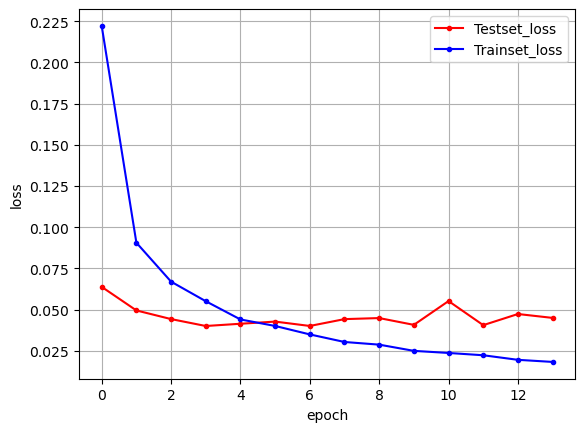

In [ ]:
# ===============================
# 1. 학습 기록(history)에서 손실 값 가져오기
# ===============================

# validation loss (검증 데이터의 손실값)
# → 모델이 "처음 보는 데이터"에서 얼마나 틀렸는지
y_vloss=history.history['val_loss']


# training loss (훈련 데이터의 손실값)
# → 모델이 "공부한 데이터"를 얼마나 잘 맞추는지
y_loss=history.history['loss']



# ===============================
# 2. x축(에폭 번호) 만들기
# ===============================

# y_loss의 길이 = 학습한 epoch 수
# 예: 30 epoch → len(y_loss) = 30

# np.arange(30) → [0, 1, 2, ..., 29]
# 이 값들이 그래프의 x축이 됨
x_len=np.arange(len(y_loss))

# ===============================
# 3. 검증 손실 그래프 (빨간색)
# ===============================
plt.plot(x_len, # x축: epoch 번호
         y_vloss, # y축: 검증 데이터 손실값
         marker='.', # 각 epoch마다 점으로 표시
         c='red',    # 선 색상: 빨간색
         label='Testset_loss')  # 범례에 표시될 이름

# 👉 이 선은
# "모델이 새로운 데이터에서도 잘 작동하는지"를 보여줌


# ===============================
# 4. 학습 손실 그래프 (파란색)
# ===============================
plt.plot(x_len,# x축: epoch 번호
         y_loss, # y축: 훈련 데이터 손실값
         marker='.',  # 점 표시
         c='blue',  # 선 색상: 파란색
         label='Trainset_loss')  # 범례 이름


# 👉 이 선은
# "모델이 훈련 데이터를 얼마나 잘 외우고 있는지"를 보여줌


# ===============================
# 5. 그래프 꾸미기
# ===============================

# 범례 표시 (오른쪽 위)
# 빨간 선 / 파란 선이 무엇을 의미하는지 알려줌

plt.legend(loc='upper right')

# 격자선 표시 → 그래프를 보기 쉽게 함
plt.grid()

# x축 이름 지정
# epoch = 학습 반복 횟수
plt.xlabel('epoch')

# y축 이름 지정
# loss = 오차 (낮을수록 좋음)
plt.ylabel('loss')


# ===============================
# 6. 그래프 출력
# ===============================

# 지금까지 설정한 모든 내용을 화면에 출력
plt.show()
